In [1]:
from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.ligsaf_settings import feed_parameters, prices
from lignin_saf.ligsaf_system import create_rcf_system
from lignin_saf.ligsaf_purification_system import create_rcf_oil_purification_system
from lignin_saf.monomer_purification import create_monomer_purification_system
from lignin_saf.ligsaf_utilities_system import create_rcf_utilities_system
from biorefineries import cellulosic
from cellulosic_tea import create_cellulosic_ethanol_tea
from biosteam import main_flowsheet as F
import biosteam as bst
import thermosteam as tmo
import numpy as np, pandas as pd
bst.nbtutorial()

In [2]:
# Code just to increase the number of display units for the various components
tmo.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
tmo.MultiStream.display_units.N = 40  
bst.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
bst.MultiStream.display_units.N = 40  

In [3]:
chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 541.7   # 2016 USD basis

# Poplar group must be defined before creating any stream that references it
chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price = prices['Feedstock'])



In [4]:
rcf_system = create_rcf_system(ins=poplar_in)
rcf_system.simulate()



In [5]:
rcf_oil_purification_sys = create_rcf_oil_purification_system(ins=F.RCF_Oil)


In [6]:
monomer_purification_sys = create_monomer_purification_system(ins=F.Purified_RCF_Oil)

In [7]:
rcf_oil_purification_sys.simulate()
monomer_purification_sys.simulate()

In [8]:
BT, WWT, gas_mixer = create_rcf_utilities_system()

In [9]:
'''
BT = bst.facilities.BoilerTurbogenerator(fuel_price = 0.2612)
WWT = bst.create_conventional_wastewater_treatment_system(
        'WWT',
        ins=(F.WW_10, 
             F.WastePulp, 
             F.RCF_WW, 
             F.WW_11, 
             F.WW_12
              ),
    )
'''

"\nBT = bst.facilities.BoilerTurbogenerator(fuel_price = 0.2612)\nWWT = bst.create_conventional_wastewater_treatment_system(\n        'WWT',\n        ins=(F.WW_10, \n             F.WastePulp, \n             F.RCF_WW, \n             F.WW_11, \n             F.WW_12\n              ),\n    )\n"

In [10]:
#BT.ins[0] = WWT.outs[1]
#gas_mixer = bst.Mixer('MIX_BT_gas', ins=(F.Purge_Light_Gases, WWT.outs[0]))
#BT.ins[1] = gas_mixer.outs[0]


In [11]:
etoh_system = cellulosic.create_cellulosic_ethanol_system(ins = F.Carbohydrate_Pulp)
etoh_system.simulate()

In [12]:
"""
 # Remove NREL Area 200 (dilute-acid pretreatment) units[2].
    for i in [FE.H2SO4_storage, FE.T201, FE.M201, FE.M203, FE.R201, FE.P201,
              FE.T202, FE.F201, FE.P201, FE.T201, FE.F201,
              FE.Ammonia_storage, FE.M204, FE.T203, FE.M205, FE.P202,
              FE.M301, FE.H301, FE.R301]:
        FE.remove_unit_and_associated_streams(i)  #[1,2]

    # Remove NREL Area 300 (SSCF fermentation) units[2].
    # These are replaced entirely by R337 (CBP reactor)[1].
    FE.remove_unit_and_associated_streams(FE.S301)

"""


# Use prices as Kay has used - data is good

'\n # Remove NREL Area 200 (dilute-acid pretreatment) units[2].\n    for i in [FE.H2SO4_storage, FE.T201, FE.M201, FE.M203, FE.R201, FE.P201,\n              FE.T202, FE.F201, FE.P201, FE.T201, FE.F201,\n              FE.Ammonia_storage, FE.M204, FE.T203, FE.M205, FE.P202,\n              FE.M301, FE.H301, FE.R301]:\n        FE.remove_unit_and_associated_streams(i)  #[1,2]\n\n    # Remove NREL Area 300 (SSCF fermentation) units[2].\n    # These are replaced entirely by R337 (CBP reactor)[1].\n    FE.remove_unit_and_associated_streams(FE.S301)\n\n'

In [13]:
#for unit in WWT.units:
#    if hasattr(unit, 'strict_moisture_content'):
#        unit.strict_moisture_content = False

In [14]:
rcf_combined_system = bst.System(
    'Combined_RCF_System',
    path=(rcf_system, 
          rcf_oil_purification_sys, 
          monomer_purification_sys, 
          WWT),
    facilities=[gas_mixer, BT],
)

In [15]:
rcf_combined_system.simulate()

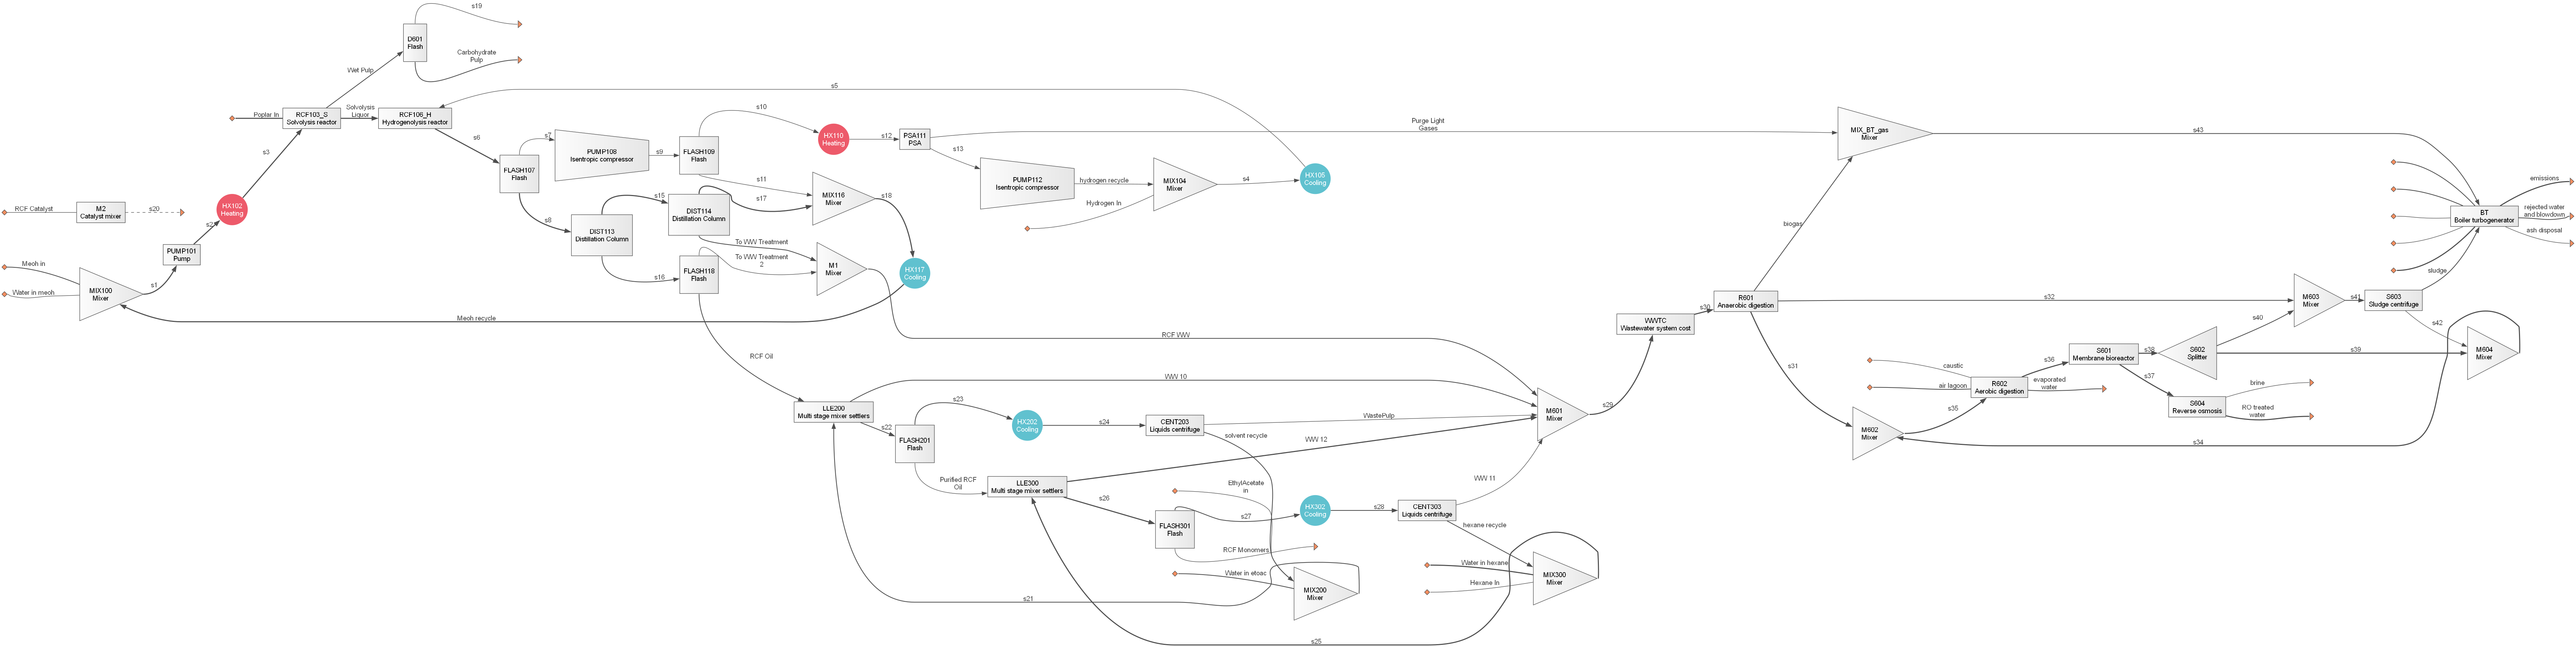

In [16]:
rcf_combined_system.diagram(format = 'png')

In [17]:
operators_per_section = 1  # operators per section from Seider recommendation
num_process_sections = 3  # number of proces sections from Seider recommendation [2 reactor, 1 separation]
num_operators_per_shift = operators_per_section * num_process_sections * 1  # multiplied by 2 for large continuous flow process (e.g., 1000 ton/day product). from Seider pg 505
num_shifts = 5  # number of shifts
pay_rate = 40  # $/hr
DWandB = num_operators_per_shift * num_shifts * 2080 * pay_rate  # direct wages and benefits. DWandB [$/year] = (operators/shift)*(5 shifts)*(40 hr/week)*(operating days/year-operator)*($/hr)
Dsalaries_benefits = 0.15 * DWandB  # direct salaries and benefits from Seider
O_supplies = 0.06 * DWandB  # Operating supplies and services from Seider
technical_assistance = 5 * 75000  # $/year. Technical assistance to manufacturing. assume 5 workers at $75000/year
control_lab = 5 * 80000  # $/year. Control laboratory. assume 5 workers at $80000/year
labor = DWandB + Dsalaries_benefits + O_supplies + technical_assistance + control_lab 

In [18]:
F.DIST113

BinaryDistillation: DIST113
ins...
[0] s8  from  Flash-FLASH107
    phase: 'l', T: 320 K, P: 500000 Pa
    flow (kmol/hr): Water           480
                    Extract         7.4
                    Acetate         48.6
                    SolubleLignin   8.8e-05
                    Glucan          23.8
                    Xylan           5.92
                    Arabinan        0.757
                    Mannan          9.51
                    Galactan        3.6
                    Methanol        1.66e+04
                    Propylguaiacol  17.4
                    Propylsyringol  14.7
                    Syringaresinol  4
                    G_Dimer         4.62
                    S_Oligomer      3.48
                    G_Oligomer      3.94
outs...
[0] s15  to  BinaryDistillation-DIST114
    phase: 'g', T: 338.65 K, P: 101325 Pa
    flow (kmol/hr): Water     464
                    Methanol  1.66e+04
[1] s16  to  Flash-FLASH118
    phase: 'l', T: 371.53 K, P: 101325 Pa
    fl

In [19]:
integrated_tea = create_cellulosic_ethanol_tea(rcf_combined_system)

In [20]:
F.Carbohydrate_Pulp

Stream: Carbohydrate_Pulp from <Flash: D601> to <FeedStockHandling: U101>
phase: 'l', T: 400 K, P: 100000 Pa
flow (kmol/hr): Sucrose   0.243
                Ash       1e+03
                Lignin    68.1
                Glucan    215
                Xylan     78.6
                Arabinan  0.505
                Mannan    9.51
                Galactan  3.6


In [21]:
integrated_tea.labor_cost = labor

In [22]:
rcf_combined_system.power_utility

PowerUtility:
consumption: 1.59e+04 kW
production: 2.11e+04 kW
power: -5.25e+03 kW
cost: -411 USD/hr


In [23]:
F.Carbohydrate_Pulp.LHV

1013187612.8561021

In [24]:
rcf_combined_system

System: Combined_RCF_System
Highest convergence error among components in recycle
streams {HX117-0, PUMP112-0} after 1 loops:
- flow rate   1.86e-10 kmol/hr (0.012%)
- temperature 1.84e-03 K (0.00059%)
ins...
[0] RCF_Catalyst  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): NiC  2.28
[1] air_lagoon  
    phase: 'g', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): N2  889
                    O2  219
[2] caustic  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water  33.4
                    NaOH   15.1
[3] Poplar_In  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water     925
                    Sucrose   0.243
                    Extract   7.4
                    Acetate   48.6
                    Ash       1e+03
                    Lignin    156
                    Glucan    238
                    Xylan     84.5
                    Arabinan  1.26
                    Mannan    19
                    Galactan  7.2
[4] Meoh_in  
    phase: 'l

In [25]:
F.RCF_Monomers.show(flow = 'kg/hr')

Stream: RCF_Monomers from <Flash: FLASH301>
phase: 'l', T: 400 K, P: 101325 Pa
flow (kg/hr): Propylguaiacol  2.89e+03
              Propylsyringol  2.89e+03


In [26]:
rcf_combined_system.power_utility

PowerUtility:
consumption: 1.59e+04 kW
production: 2.11e+04 kW
power: -5.25e+03 kW
cost: -411 USD/hr


In [27]:
F.Carbohydrate_Pulp

Stream: Carbohydrate_Pulp from <Flash: D601> to <FeedStockHandling: U101>
phase: 'l', T: 400 K, P: 100000 Pa
flow (kmol/hr): Sucrose   0.243
                Ash       1e+03
                Lignin    68.1
                Glucan    215
                Xylan     78.6
                Arabinan  0.505
                Mannan    9.51
                Galactan  3.6


In [28]:
print(f'The MSP for RCF monomers is  {round(integrated_tea.solve_price(F.RCF_Monomers),3)} USD/kg')

The MSP for RCF monomers is  8.894 USD/kg


In [29]:
print('CAPEX', round(rcf_combined_system.installed_equipment_cost / 1e6, 2), 'MMUSD')
print('OPEX', round((rcf_combined_system.material_cost + rcf_combined_system.utility_cost) / 1e6, 3), 'MMUSD/yr')

CAPEX 395.01 MMUSD
OPEX 304.034 MMUSD/yr


In [30]:
celly = create_cellulosic_ethanol_system()

NameError: name 'create_cellulosic_ethanol_system' is not defined

In [ ]:
BREAK

NameError: name 'BREAK' is not defined

In [ ]:
BREAK

NameError: name 'BREAK' is not defined

In [ ]:
F.BT

BoilerTurbogenerator: BT
ins...
[0] sludge  from  SludgeCentrifuge-S603
    phase: 'l', T: 307.93 K, P: 101325 Pa
    flow (kmol/hr): Water           1.47e+03
                    Extract         0.00313
                    Acetate         1.19
                    NaOH            1.19
                    SolubleLignin   6.12e-08
                    Glucan          18.1
                    Xylan           4.53
                    Arabinan        0.726
                    Mannan          9.12
                    Galactan        3.45
                    WWTsludge       54.2
                    Methanol        0.0108
                    Hexane          0.000596
                    EthylAcetate    0.00677
                    Propylguaiacol  9.01e-07
                    Propylsyringol  7.63e-07
                    Syringaresinol  0.00306
                    G_Dimer         0.00353
                    S_Oligomer      0.00561
                    G_Oligomer      0.00636
[1] s46  from  Mixer-MIX_

In [ ]:
# rcf_combined_system.units

In [ ]:
# Different sections

rcf_area= [F.MIX100, F.PUMP101, F.HX102, F.RCF103_S, F.MIX104, F.HX105, F.RCF106_H, F.FLASH107, F.PUMP108,
F.FLASH109, F.HX110, F.PSA111, F.PUMP112, F.DIST113, F.DIST114, F.MIX116, F.HX117, F.FLASH118, F.M1, F.D601,F.M2]

rcf_oil_purification = [F.MIX200, F.LLE200, F.FLASH201, F.HX202, F.CENT203]

monomer_purification = [F.MIX300, F.LLE300, F.FLASH301, F.HX302, F.CENT303]

BT = [BT]

WWT = [WWT]

In [ ]:
# --- Export net system boundary flows to CSV ---
chem_ids = [c.ID for c in chems]

rows = []
for s in rcf_combined_system.feeds:
    comp_flows = {c: s.imass[c] for c in chem_ids}
    rows.append({'Stream': s.ID, 'Direction': 'Input', 'Phase': s.phase,
                 'Total_kg_hr': s.F_mass, **comp_flows})
for s in rcf_combined_system.products:
    comp_flows = {c: s.imass[c] for c in chem_ids}
    rows.append({'Stream': s.ID, 'Direction': 'Output', 'Phase': s.phase,
                 'Total_kg_hr': s.F_mass, **comp_flows})

df = pd.DataFrame(rows).set_index(['Stream', 'Direction', 'Phase', 'Total_kg_hr'])
# Drop columns where every stream has zero flow
df = df.loc[:, (df != 0).any(axis=0)]
df = df.reset_index()
df.to_csv('rcf_system_boundary_flows.csv', index=False)
print('Saved rcf_system_boundary_flows.csv')

Saved rcf_system_boundary_flows.csv


In [ ]:
rcf_area_ic = sum(u.installed_cost for u in rcf_area)
rcf_oil_purification_ic = sum(u.installed_cost for u in rcf_oil_purification)
rcf_monomer_purification_ic = sum(u.installed_cost for u in monomer_purification)
BT_installed_cost = F.BT.installed_cost
WWT_installed_cost  = F.WWTC.installed_cost
installed_costs_arr = np.array([rcf_area_ic, rcf_oil_purification_ic, rcf_monomer_purification_ic, 
                            BT_installed_cost, WWT_installed_cost])

In [ ]:
np.sum(installed_costs_arr)

395010178.23831844

In [ ]:
rcf_combined_system.show(flow = 'kg/hr')

System: Combined_RCF_System
Highest convergence error among components in recycle
streams {HX117-0, PUMP112-0} after 1 loops:
- flow rate   1.86e-10 kmol/hr (0.012%)
- temperature 1.84e-03 K (0.00059%)
ins...
[0] RCF_Catalyst  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kg/hr): NiC  2.28
[1] air_lagoon  
    phase: 'g', T: 298.15 K, P: 101325 Pa
    flow (kg/hr): N2  2.49e+04
                  O2  7.02e+03
[2] caustic  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kg/hr): Water  602
                  NaOH   602
[3] Poplar_In  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kg/hr): Water     1.67e+04
                  Sucrose   83.3
                  Extract   1.33e+03
                  Acetate   2.92e+03
                  Ash       1e+03
                  Lignin    2.38e+04
                  Glucan    3.87e+04
                  Xylan     1.12e+04
                  Arabinan  167
                  Mannan    3.08e+03
                  Galactan  1.17e+03
[4] Meoh_in  


Font: Arial


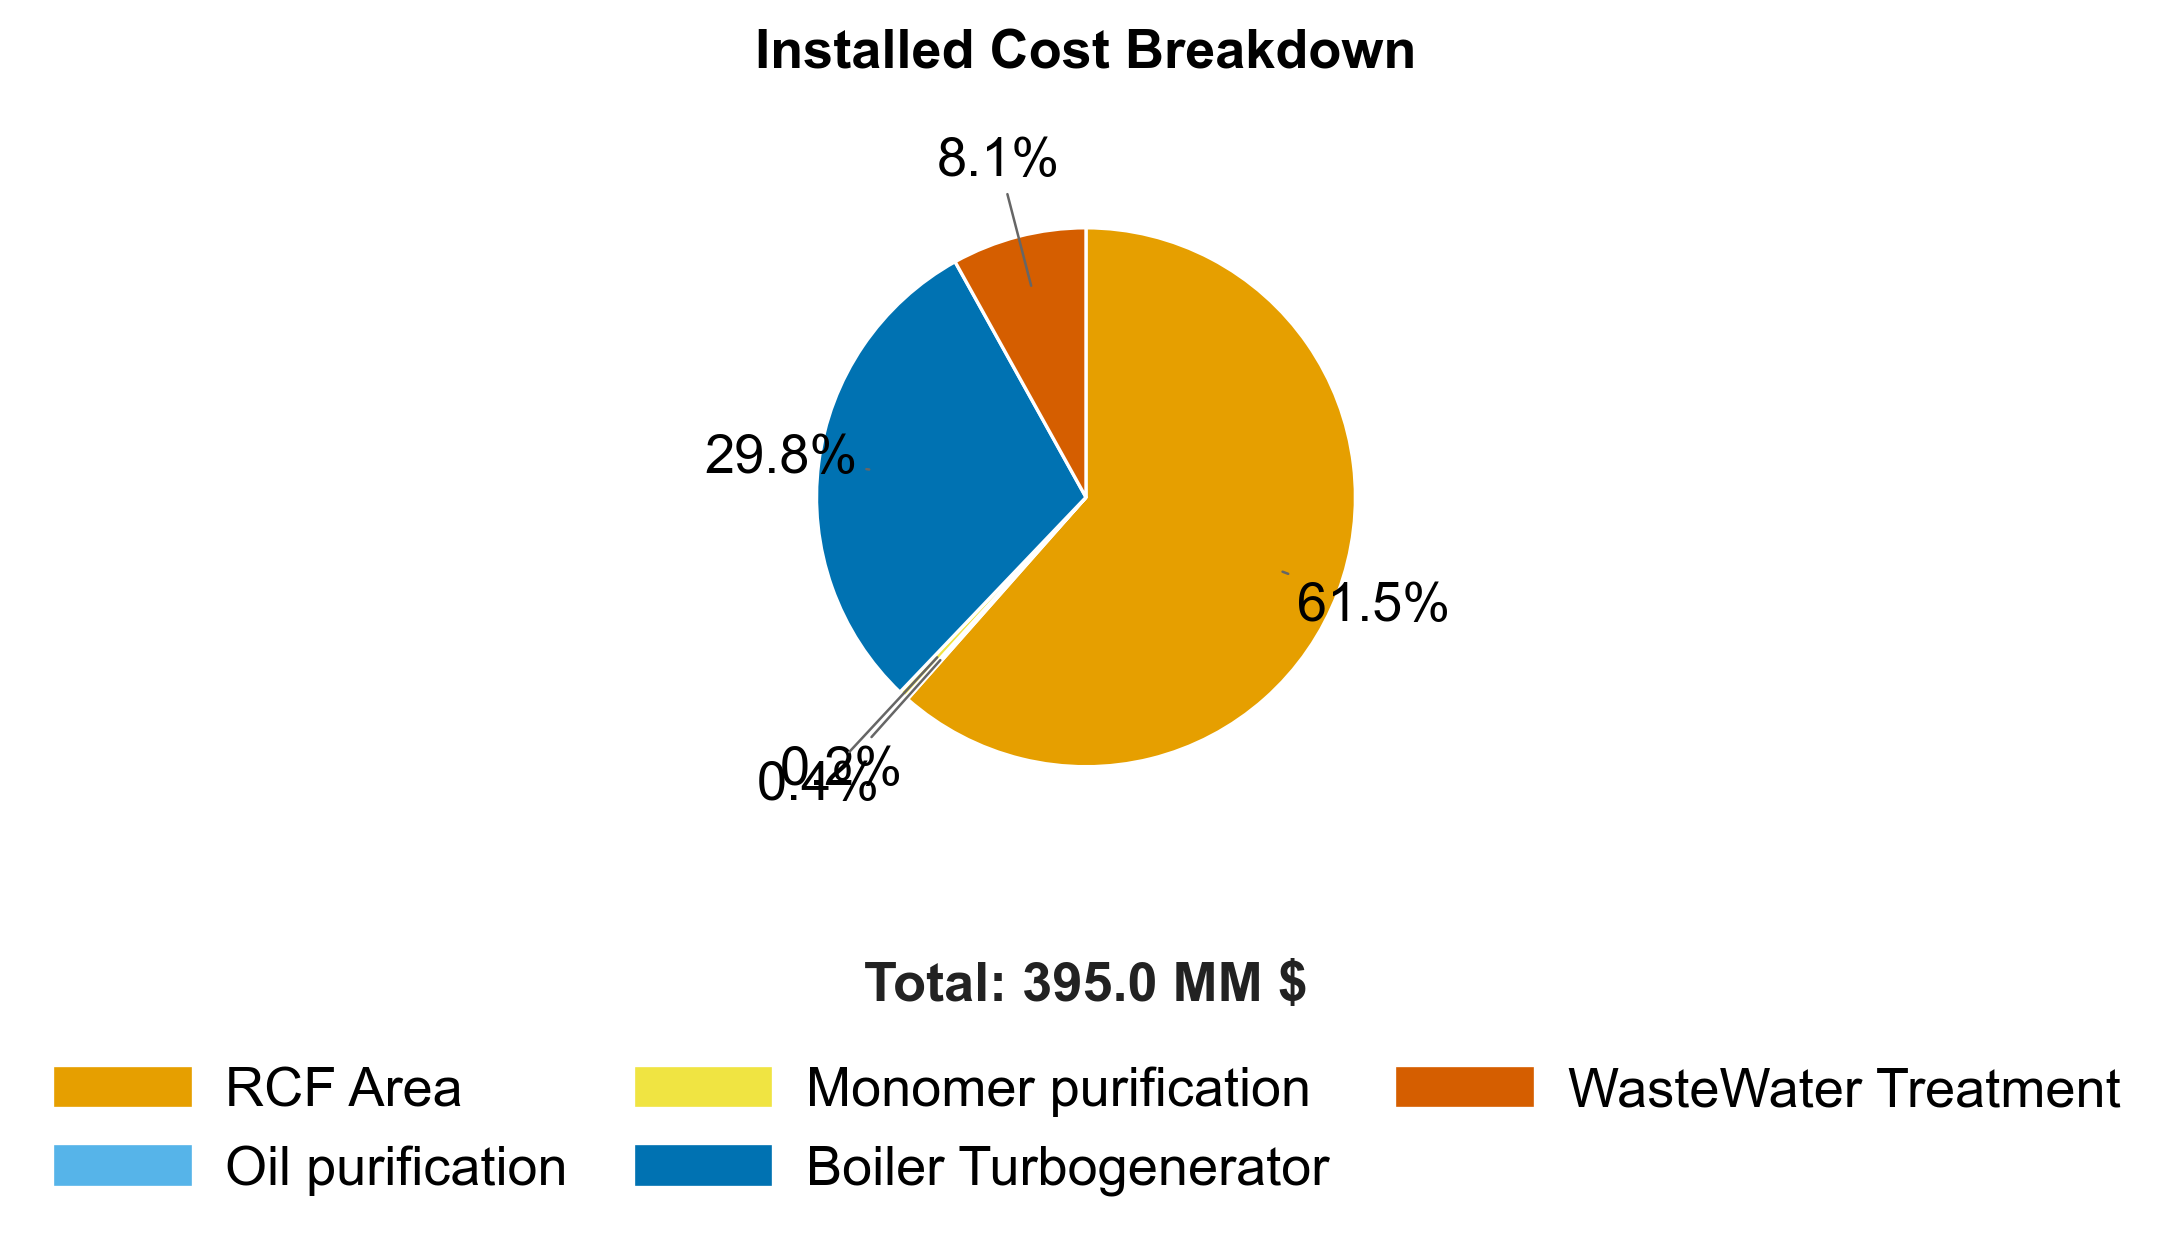

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Font ──────────────────────────────────────────────────────────────────────
font_pref = ["Arial", "Liberation Sans", "DejaVu Sans"]
available = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
chosen = next((f for f in font_pref if f in available), "DejaVu Sans")
print(f"Font: {chosen}")

plt.rcParams.update({
    "font.family": chosen,
    "mathtext.fontset": "custom",
    "mathtext.rm": chosen,
    "mathtext.it": chosen,
    "mathtext.bf": chosen,
})

plt.rcParams['svg.fonttype'] = 'none'

oi_colors = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
]

categories = [
    "RCF Area",
    "Oil purification",
    "Monomer purification",
    "Boiler Turbogenerator",
    "WasteWater Treatment",
]

values = [
    rcf_area_ic,
    rcf_oil_purification_ic,
    rcf_monomer_purification_ic,
    BT_installed_cost,
    WWT_installed_cost,
]

# ── Figure ────────────────────────────────────────────────────────────────────
DPI      = 300
fig_w_px = 1500
fig_h_px = 1260
fig_w_in = fig_w_px / DPI
fig_h_in = fig_h_px / DPI

FS_TITLE  = 13
FS_TOTAL  = 13
FS_PCT    = 13
FS_LEGEND = 13

fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in))

# ── draw_pie ──────────────────────────────────────────────────────────────────
def draw_pie(ax, vals, title):
    total = sum(vals)
    total_kt = total / 1e6
    fracs = [v / total for v in vals]

    wedges, _ = ax.pie(
        vals,
        colors=oi_colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(linewidth=0.8, edgecolor="white"),
    )

    label_data = []
    for i, (wedge, frac) in enumerate(zip(wedges, fracs)):
        pct   = frac * 100
        theta = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
        if pct >= 20:   r_out = 1.14
        elif pct >= 10: r_out = 1.21
        elif pct >= 5:  r_out = 1.29
        else:           r_out = 1.38
        label_data.append(dict(theta=theta, pct=pct, r_out=r_out, r_in=0.78, idx=i))

    small_indices = [d["idx"] for d in label_data if d["pct"] < 5]
    for j, idx in enumerate(small_indices):
        label_data[idx]["r_out"] = 1.36 if j % 2 == 0 else 1.46

    for d in label_data:
        theta, r_in, r_out, pct = d["theta"], d["r_in"], d["r_out"], d["pct"]
        ax.annotate(
            f"{pct:.1f}%",
            xy=(r_in  * np.cos(theta), r_in  * np.sin(theta)),
            xytext=(r_out * np.cos(theta), r_out * np.sin(theta)),
            fontsize=FS_PCT,
            ha="center", va="center",
            arrowprops=dict(
                arrowstyle="-", color="#666666", lw=0.6,
                shrinkA=0, shrinkB=2,
            ),
        )

    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=6)
    ax.text(0, -1.72,
            r"Total: " + f"{rcf_combined_system.installed_cost/1e6:.1f}" + r" MM $",
            ha="center", va="top", fontsize=FS_TOTAL,
            color="#222222", fontweight="bold", style="normal")

    ax.set_xlim(-1.65, 1.65)
    ax.set_ylim(-1.95, 1.50)

draw_pie(ax, values, "Installed Cost Breakdown")

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(facecolor=c, edgecolor="white", linewidth=0.8, label=lbl)
    for c, lbl in zip(oi_colors, categories)
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=3,
    fontsize=FS_LEGEND,
    frameon=False,
    columnspacing=1.2,
    handlelength=2.6,
    handleheight=0.85,
    handletextpad=0.6,
    bbox_to_anchor=(0.5, 0.0),
)

plt.rcParams['svg.fonttype'] = 'none'

fig.tight_layout(rect=[0, 0.14, 1, 1])

#fig.savefig("ghg_pie_chart.png", dpi=DPI, bbox_inches="tight")
fig.savefig("installed_cost_breakdown_2.svg", format="svg", bbox_inches="tight")
#print("Done.")

In [ ]:
# Operating costs plot
methanol_price = F.Meoh_in.F_mass * prices['Methanol'] * integrated_tea.operating_hours
hydrogen_price = F.Hydrogen_In.F_mass * prices['Hydrogen'] * integrated_tea.operating_hours
poplar_price = F.Poplar_In.F_mass * prices['Feedstock'] * integrated_tea.operating_hours
ethyl_acetate_price = F.EthylAcetate_in.F_mass * prices['EthylAcetate'] * integrated_tea.operating_hours
hexane_price = F.Hexane_In.F_mass * prices['Hexane'] * integrated_tea.operating_hours
catalyst = F.RCF_Catalyst.F_mass * prices['NiC_catalyst'] * integrated_tea.operating_hours
#natural_gas = 5.35e+04 * 0.2612 * integrated_tea.operating_hours
material_arrz = np.array([methanol_price, hydrogen_price, poplar_price, 
                            ethyl_acetate_price, hexane_price, catalyst])

Font: Arial


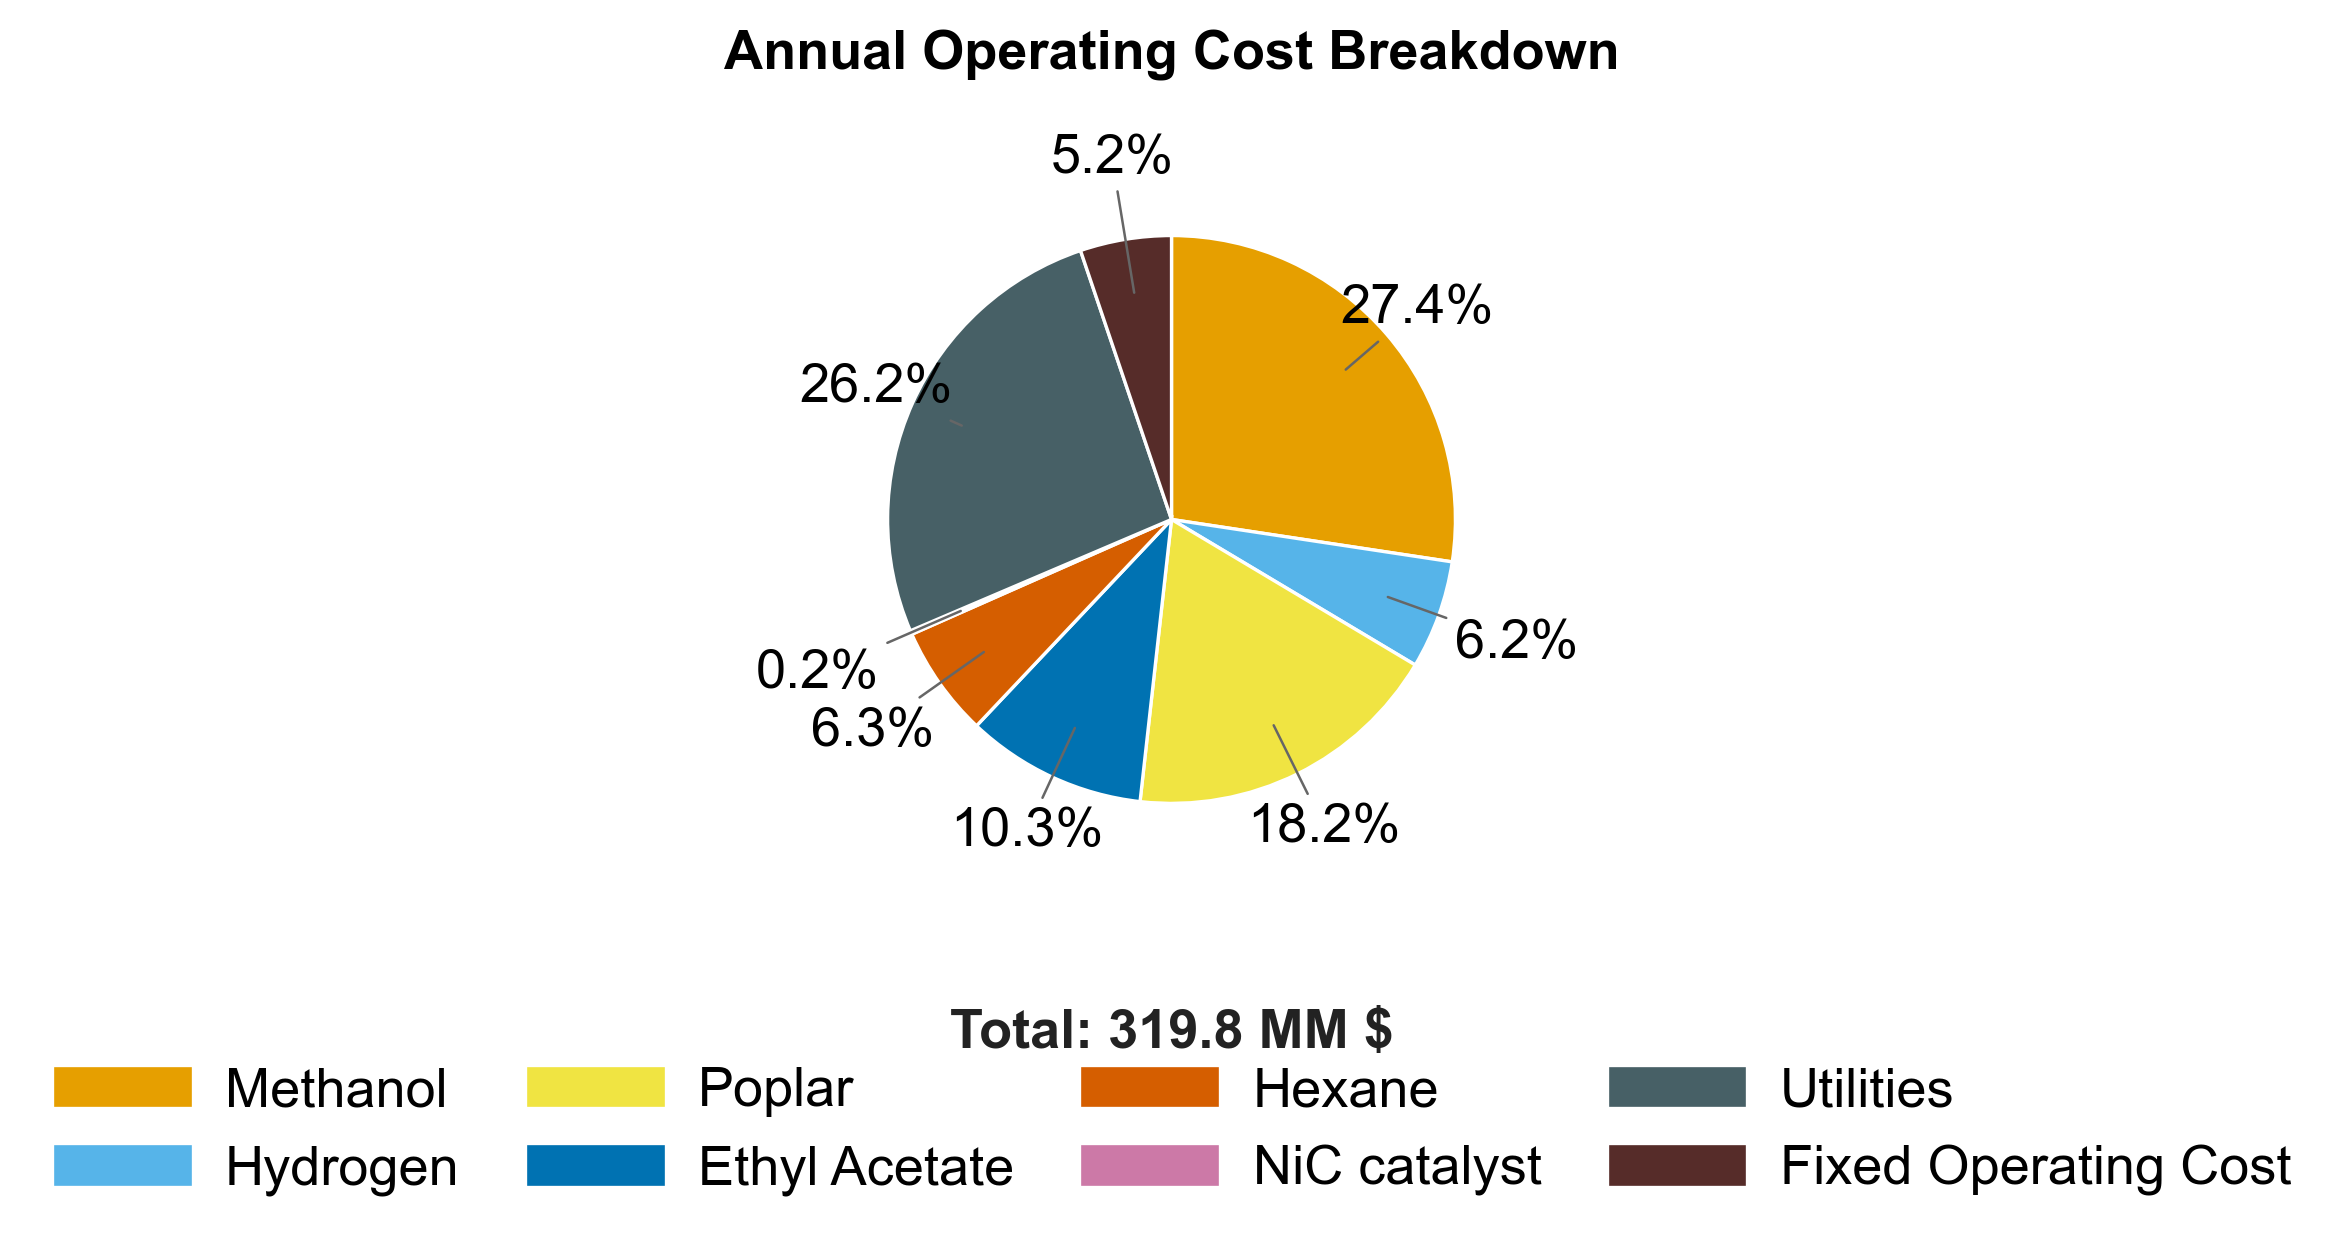

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Font ──────────────────────────────────────────────────────────────────────
font_pref = ["Arial"]
available = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
chosen = next((f for f in font_pref if f in available), "DejaVu Sans")
print(f"Font: {chosen}")

plt.rcParams.update({
    "font.family": chosen,
    "mathtext.fontset": "custom",
    "mathtext.rm": chosen,
    "mathtext.it": chosen,
    "mathtext.bf": chosen,
})

plt.rcParams['svg.fonttype'] = 'none'

oi_colors = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#476066",  # dark teal
    "#562C29",  # dark brown
]

categories = [
    "Methanol",
    "Hydrogen",
    "Poplar",
    "Ethyl Acetate",
    "Hexane",
    "NiC catalyst",
    "Utilities",
    "Fixed Operating Cost",
]



values = [
    methanol_price,
    hydrogen_price,
    poplar_price,
    ethyl_acetate_price,
    hexane_price,
    catalyst,
    integrated_tea.utility_cost,
    integrated_tea.FOC,
]

# ── Figure ────────────────────────────────────────────────────────────────────
DPI      = 300
fig_w_px = 1500
fig_h_px = 1260
fig_w_in = fig_w_px / DPI
fig_h_in = fig_h_px / DPI

FS_TITLE  = 13
FS_TOTAL  = 13
FS_PCT    = 13
FS_LEGEND = 13

fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in))

# ── draw_pie ──────────────────────────────────────────────────────────────────
def draw_pie(ax, vals, title):
    total    = sum(vals)
    total_MM = total / 1e6
    fracs    = [v / total for v in vals]

    wedges, _ = ax.pie(
        vals,
        colors=oi_colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(linewidth=0.8, edgecolor="white"),
    )

    label_data = []
    for i, (wedge, frac) in enumerate(zip(wedges, fracs)):
        pct   = frac * 100
        theta = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
        if pct >= 20:   r_out = 1.14
        elif pct >= 10: r_out = 1.21
        elif pct >= 5:  r_out = 1.29
        else:           r_out = 1.38
        label_data.append(dict(theta=theta, pct=pct, r_out=r_out, r_in=0.78, idx=i))

    small_indices = [d["idx"] for d in label_data if d["pct"] < 5]
    for j, idx in enumerate(small_indices):
        label_data[idx]["r_out"] = 1.36 if j % 2 == 0 else 1.46

    for d in label_data:
        theta, r_in, r_out, pct = d["theta"], d["r_in"], d["r_out"], d["pct"]
        ax.annotate(
            f"{pct:.1f}%",
            xy=(r_in  * np.cos(theta), r_in  * np.sin(theta)),
            xytext=(r_out * np.cos(theta), r_out * np.sin(theta)),
            fontsize=FS_PCT,
            ha="center", va="center",
            arrowprops=dict(
                arrowstyle="-", color="#666666", lw=0.6,
                shrinkA=0, shrinkB=2,
            ),
        )

    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=6)
    ax.text(0, -1.72,
            r"Total: " + f"{total_MM:.1f}" + r" MM $",
            ha="center", va="top", fontsize=FS_TOTAL,
            color="#222222", fontweight="bold", style="normal")

    ax.set_xlim(-1.65, 1.65)
    ax.set_ylim(-1.95, 1.50)

draw_pie(ax, values, "Annual Operating Cost Breakdown")

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(facecolor=c, edgecolor="white", linewidth=0.8, label=lbl)
    for c, lbl in zip(oi_colors, categories)
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    fontsize=FS_LEGEND,
    frameon=False,
    columnspacing=1.2,
    handlelength=2.6,
    handleheight=0.85,
    handletextpad=0.6,
    bbox_to_anchor=(0.5, 0.0),
)

fig.tight_layout(rect=[0, 0.10, 1, 1])

fig.savefig("operating_breakdown_2.svg", format="svg", bbox_inches="tight")
#print("Done.")

In [ ]:
integrated_tea.utility_cost 

83842538.52551803

In [ ]:
rcf_combined_system.material_cost

220191927.48427755

In [ ]:
rcf_combined_system.feeds

[<Stream: Meoh_in>,
 <Stream: Water_in_meoh>,
 <Stream: Poplar_In>,
 <Stream: Hydrogen_In>,
 <Stream: RCF_Catalyst>,
 <Stream: EthylAcetate_in>,
 <Stream: Water_in_etoac>,
 <Stream: Hexane_In>,
 <Stream: Water_in_hexane>,
 <Stream: air_lagoon>,
 <Stream: caustic>,
 <Stream>,
 <Stream>,
 <Stream>,
 <Stream>,
 <Stream>]

In [ ]:
print('OPEX', round((rcf_combined_system.material_cost + rcf_combined_system.utility_cost) / 1e6, 3), 'MMUSD/yr')


OPEX 304.034 MMUSD/yr


In [ ]:
F.BT.results()

Boiler turbogenerator                                      Units        BT
Electricity           Power                                   kW -1.12e+04
                      Cost                                USD/hr      -874
High pressure steam   Duty                                 kJ/hr  -9.6e+08
                      Flow                               kmol/hr -2.98e+04
                      Cost                                USD/hr -9.46e+03
Low pressure steam    Duty                                 kJ/hr  -7.5e+08
                      Flow                               kmol/hr -1.94e+04
                      Cost                                USD/hr -4.61e+03
Cooling water         Duty                                 kJ/hr -1.01e+07
                      Flow                               kmol/hr   6.9e+03
                      Cost                                USD/hr      3.36
Fuel (inlet)          Flow                                 kg/hr   2.9e+04
                      Cost                                USD/hr  7.57e+03
Ash disposal (outlet) Flow                                 kg/hr      64.6
                      Cost                                USD/hr      2.05
Design                Work                                    kW  1.59e+04
                      Flow rate                            kg/hr  8.21e+05
                      Ash disposal                         kg/hr      64.6
Purchase cost         Baghouse bags                          USD  6.78e+03
                      Boiler                                 USD  5.89e+07
                      Deaerator                              USD  6.34e+05
                      Amine addition pkg                     USD  8.31e+04
                      Hot process water softener system      USD  1.62e+05
                      Turbogenerator                         USD   5.2e+06
Total purchase cost                                          USD   6.5e+07
Utility cost                                              USD/hr -7.37e+03

In [ ]:
rcf_combined_system.show(flow = 'kg/hr')

System: Combined_RCF_System
Highest convergence error among components in recycle
streams {HX117-0, PUMP112-0} after 1 loops:
- flow rate   1.86e-10 kmol/hr (0.012%)
- temperature 1.84e-03 K (0.00059%)
ins...
[0] RCF_Catalyst  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kg/hr): NiC  2.28
[1] air_lagoon  
    phase: 'g', T: 298.15 K, P: 101325 Pa
    flow (kg/hr): N2  2.49e+04
                  O2  7.02e+03
[2] caustic  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kg/hr): Water  602
                  NaOH   602
[3] Poplar_In  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kg/hr): Water     1.67e+04
                  Sucrose   83.3
                  Extract   1.33e+03
                  Acetate   2.92e+03
                  Ash       1e+03
                  Lignin    2.38e+04
                  Glucan    3.87e+04
                  Xylan     1.12e+04
                  Arabinan  167
                  Mannan    3.08e+03
                  Galactan  1.17e+03
[4] Meoh_in  
